In [37]:
import io # Input/Output Module
import os # OS interfaces
import cv2 # OpenCV package
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv1D, Flatten, Activation
from keras import regularizers
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from keras.callbacks import EarlyStopping
from keras.callbacks import CSVLogger
from keras.callbacks import ProgbarLogger

In [38]:
#Prepare the data for triplet model
features = np.load('group16_features.npz', allow_pickle=False) #preprocessed features

#training data, the extracted features + the preprocessed images
#hog_features
hog_train = features["hog_train"]
hog_test = features["hog_test"]
#SIFT features
sift_train = features["sift_train"]
sift_test = features["sift_test"]
#PCA features
pca_train = features["pca_train"]
pca_test = features["pca_test"]
#fused features
fused_train = np.hstack([hog_train,sift_train])
fused_test = np.hstack([hog_test,sift_test])

#original images
images_train = np.load('./kaggle/working/prepped_data/train_X.npy', allow_pickle=False)
#images_train2 = np.concatenate((images_train,images_train[:, :, ::-1, :]),axis=0)
images_test = np.load('./kaggle/working/prepped_data/test_X.npy', allow_pickle=False)

labels = features["train_y"] #fetch the labels
if(np.size(hog_train,axis=0) >=80):
    labels = np.concatenate([labels,labels],axis=0)
    pca_train = np.concatenate([pca_train,pca_train],axis=0)
    images_train = np.concatenate([images_train,     images_train[:, :, ::-1, :]], axis=0)

#super fused features
super_fused_train = np.hstack([pca_train,fused_train])
super_fused_test = np.hstack([pca_test,fused_test])

In [39]:
#While training the triplet model, we want to assign the correct lookalikes as hard negatives for the anchors
#We will construct a new label set which will split the lookalikes class into male/female
import cv2
import numpy as np

# Load pretrained gender model (Caffe)
gender_net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "gender_net.caffemodel")
gender_list = ["Male", "Female"]

# Your image (128,128,3)
gender_data = []
for img in images_train:


    blob = cv2.dnn.blobFromImage(img, 1.0, (227, 227),
                              (78.4263377603, 87.7689143744, 114.895847746),
                              swapRB=False)

    gender_net.setInput(blob)
    preds = gender_net.forward()
    gender = gender_list[preds[0].argmax()]
    #Jesse = 1, Mila = 2, Lookalike = 0
    gender_data.append(gender)
gender_array = np.array(gender_data)

In [40]:
def triplet_batch_generator(X, y, gender_array,images,batch_size,threshold):

    def augment(x):
        noise = np.random.normal(0, 0.01, size=x.shape)
        scale = np.random.uniform(0.9, 1.1)
        return x * scale + noise

    # Separate indices by class
    idx_p1 = np.where(y == 1)[0] #Jesse, Male
    idx_p2 = np.where(y == 2)[0] #Mila, Female
    idx_lookalike_male = np.where((y == 0)  &   (gender_array == "Male"))[0] #Lookalikes, male and female mixed
    idx_lookalike_female = np.where((y == 0)  &   (gender_array == "Female"))[0]
    while True:
        A_batch, P_batch, N_batch = [], [], []
        A_img_batch, P_img_batch, N_img_batch = [],[],[]

        for _ in range(batch_size):
            # Anchor: pick from Person1 or Person2, x-tra: also pick anchors from the final class
            anchor_class = np.random.choice([0, 1,2],p=[0.35, 0.35, 0.30])

            if anchor_class == 1:
                idx_anchor_pool = idx_p1
            elif anchor_class == 2:
                idx_anchor_pool = idx_p2
            else:
                # For lookalikes, anchor and positive come from the same gender subgroup
                idx_anchor_pool = idx_lookalike_male if np.random.rand() < 0.5 else idx_lookalike_female

            anchor_idx = np.random.choice(idx_anchor_pool)
            anchor     = X[anchor_idx]
            img_A      = images[anchor_idx]
            #anchor = augment(anchor)


            # Positive: same subgroup
            pos_pool = idx_anchor_pool[idx_anchor_pool != anchor_idx]
            positive_idx = np.random.choice(pos_pool)
            positive     = X[positive_idx]
            img_P        = images[positive_idx]
            #positive = augment(positive)

            # Negative: the other class(es)
            number = np.random.rand()

            if anchor_class == 1:
                if number < threshold:
                    neg_pool = np.concatenate([idx_p2, idx_lookalike_female],axis=0)
                else:
                    neg_pool = idx_lookalike_male

            elif anchor_class == 2:
                if number < threshold:
                    neg_pool = np.concatenate([idx_p1,idx_lookalike_male],axis=0)
                else:
                    neg_pool = idx_lookalike_female

            else:
                neg_pool = np.concatenate([idx_p1, idx_p2])
            negative_idx = np.random.choice(neg_pool)
            negative = X[negative_idx]
            img_N    = images[negative_idx]
            #negative = augment(negative)




            """ #Tuneability on hard negatives
            # Negative: 50% chance easy (other person), 50% hard (lookalike)
            if np.random.rand() < 0.4:
                neg_pool = idx_p2 if anchor_class == 0 else idx_p1
            else:
                neg_pool = idx_lookalike_male if anchor_class == 0 else idx_lookalike_female
            negative_idx = np.random.choice(neg_pool)
            negative = X[negative_idx]
            #negative = augment(negative)
            """

            # Add to batch
            A_batch.append(anchor)
            P_batch.append(positive)
            N_batch.append(negative)
            A_img_batch.append(img_A)
            P_img_batch.append(img_P)
            N_img_batch.append(img_N)

        # Convert to arrays
        A_batch = np.stack(A_batch, axis=0)
        P_batch = np.stack(P_batch, axis=0)
        N_batch = np.stack(N_batch, axis=0)
        A_img_batch = np.stack(A_img_batch, axis=0)
        P_img_batch = np.stack(P_img_batch, axis=0)
        N_img_batch = np.stack(N_img_batch, axis=0)
        # dummy labels (ignored by loss)
        dummy_labels = np.zeros((batch_size,))

        yield (A_img_batch, A_batch, P_img_batch, P_batch, N_img_batch, N_batch), dummy_labels

def get_backbone(model_name, input_shape=(128,128,3)):
    if model_name == "resnet50":
        base = tf.keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    elif model_name == "efficientnet_b0":
        base = tf.keras.applications.EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    elif model_name == "efficientnet_b4":
        base = tf.keras.applications.EfficientNetB4(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
    else:
        raise ValueError(f"Unknown model {model_name}")

    return base

In [41]:
def HOG_embedding_model(input_shape=(100,),embedding_dim=64,backbone_name = "resnet50"):

    #embedding_dim param determines the length of the vector we will use to represent our images
    #The model for one of the branches in the triplet model, (parameters should be tied)
    ##############################
    #Bottom branch implementation
    ##############################
    input_HOG = tf.keras.layers.Input(shape=input_shape,name="HOG_features")

    x = tf.keras.layers.Flatten()(input_HOG)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(32)(x)

    #################################
    #Top branch implementation
    #################################
    input_image = tf.keras.layers.Input(shape=(128,128,3),name="face_images")
    #Normalisation
    #input_image_BN = tf.keras.layers.BatchNormalization()(input_image) #Article uses raw images  
    #Pass through a pretrained network
    base_model = get_backbone(backbone_name)

    # Optional: freeze backbone
    base_model.trainable = False
    x2 = base_model(input_image, training=False)
    #This is passed to a 64 channel 3x3  2D convolutional filter
    x2 = tf.keras.layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu', padding='same')(x2)
    # Max pooling layer with 2x2 window
    x2 = tf.keras.layers.MaxPooling2D(pool_size=(2,2))(x2)
    # Flatten the output
    x2 = tf.keras.layers.Flatten()(x2)
    # Dense layer with 64 ReLU-activated units
    image_embedding = tf.keras.layers.Dense(64, activation='relu')(x2)

    ##############################
    #Concatenation of branches implementation
    ##############################
    # Concatenate image and HOG features
    concat_features = tf.keras.layers.Concatenate()([image_embedding, x])
    #One more fully connected block
    x3 = tf.keras.layers.Dense(64, activation='relu')(concat_features)
    x3 = tf.keras.layers.Dropout(0.4)(x3)
    x3 = tf.keras.layers.Dense(embedding_dim, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x3)

    # normalize embedding
    output = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x3)

    model = tf.keras.Model(inputs=[input_image, input_HOG], outputs=output)

    return model

def build_triplet_model(embedding_model ,input_shape=(100,)):
    #the model combining lookalikes and the original classes to produce anchors, positives and negatives

    input_A = tf.keras.layers.Input(shape=input_shape, name="anchor")
    input_P = tf.keras.layers.Input(shape=input_shape, name="positive")
    input_N = tf.keras.layers.Input(shape=input_shape, name="negative")

    input_A_img = tf.keras.layers.Input(shape=(128,128,3), name="anchor_img")
    input_P_img = tf.keras.layers.Input(shape=(128,128,3), name="positive_img")
    input_N_img = tf.keras.layers.Input(shape=(128,128,3), name="negative_img")

    zA = embedding_model([input_A_img,input_A])
    zP = embedding_model([input_P_img,input_P])
    zN = embedding_model([input_N_img,input_N])

    # concatenate for loss computation
    output = tf.keras.layers.Concatenate(axis=1)([zA, zP, zN])

    model = tf.keras.Model(
        inputs=[input_A_img, input_A, input_P_img, input_P, input_N_img, input_N],
        outputs=output
    )

    return model

def triplet_loss(margin=0.5):

    def loss(y_true, y_pred):
        # split embeddings
        dim = y_pred.shape[1] // 3

        zA = y_pred[:, 0:dim]
        zP = y_pred[:, dim:2*dim]
        zN = y_pred[:, 2*dim:3*dim]

        # distances
        d_pos = tf.reduce_sum(tf.square(zA - zP), axis=1)
        d_neg = tf.reduce_sum(tf.square(zA - zN), axis=1)

        # triplet loss
        return tf.reduce_mean(tf.maximum(0.0, d_pos - d_neg + margin))

    return loss

In [42]:
# -----------------------------
# 7. Build models
# -----------------------------
#Try for HOG first
embedding_dim = 32
features = hog_train
features_test = hog_test
shape = np.size(features,axis=1)
margin = 0.5
backbone_name = "resnet50"


embedding_model = HOG_embedding_model(input_shape=(shape,), embedding_dim=embedding_dim,backbone_name=backbone_name)
triplet_model = build_triplet_model(embedding_model, input_shape=(shape,))

triplet_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss=triplet_loss(margin=margin))

triplet_model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor_img          │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ anchor (InputLayer) │ (None, 972)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive_img        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 972)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative_img        │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 972)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_7        │ (None, 32)        │ 24,033,856 │ anchor_img[0][0], │
│ (Functional)        │                   │            │ anchor[0][0],     │
│                     │                   │            │ positive_img[0][… │
│                     │                   │            │ positive[0][0],   │
│                     │                   │            │ negative_img[0][… │
│                     │                   │            │ negative[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 96)        │          0 │ functional_7[0][… │
│ (Concatenate)       │                   │            │ functional_7[1][… │
│                     │                   │            │ functional_7[2][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,033,856 (91.68 MB)

 Trainable params: 444,200 (1.69 MB)

 Non-trainable params: 23,589,656 (89.99 MB)

In [43]:
train_gen = triplet_batch_generator(features, labels, gender_array,images_train,batch_size=16,threshold=0.5)

early_stop = EarlyStopping(
    monitor='loss',       # or val_loss if you add validation
    patience=5,
    restore_best_weights=True
)

triplet_model.fit(
    train_gen,
    steps_per_epoch=30,
    epochs=200,
    callbacks=[early_stop]
)

embeddings = embedding_model.predict([images_train,features])

Epoch 1/200


30/30 ━━━━━━━━━━━━━━━━━━━━ 28s 403ms/step - loss: 0.4642
Epoch 2/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - loss: 0.2446
Epoch 3/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 13s 432ms/step - loss: 0.2176
Epoch 4/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 453ms/step - loss: 0.1182
Epoch 5/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 463ms/step - loss: 0.0648
Epoch 6/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 469ms/step - loss: 0.0370
Epoch 7/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 503ms/step - loss: 0.0353
Epoch 8/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 493ms/step - loss: 0.0382
Epoch 9/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 484ms/step - loss: 0.0360
Epoch 10/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 485ms/step - loss: 0.0324
Epoch 11/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 484ms/step - loss: 0.0310
Epoch 12/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 482ms/step - loss: 0.0314
Epoch 13/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 481ms/step - loss: 0.0314
Epoch 14/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 482ms/step - loss: 0.0378
Epoch 15/200
30/30 ━━━━━━━━━━━━━━━━━━━━ 1

In [44]:
embeddings = embedding_model.predict([images_train,features])

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step


In [48]:
embeddings_test = embedding_model.predict([images_test,features_test])

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC

param_grid = {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
gs = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', probability=True),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy'
)
gs.fit(embeddings, labels)
clf = gs.best_estimator_
print(f"Best SVM params: {gs.best_params_}")

y_pred = clf.predict(embeddings_test)

57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 273ms/step
Best SVM params: {'C': 0.1, 'gamma': 'scale'}


In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Concatenate HOG and SIFT into one feature vector per sample
combined_train = embeddings
combined_test  = embeddings_test


pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(decision_function_shape='ovr'))
])

param_grid = {
    'clf__kernel': ['rbf', 'linear'],
    'clf__C':      [0.01, 0.1, 1, 10],
    'clf__gamma':  ['scale', 'auto', 0.001, 0.01]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', refit=True)
grid_search.fit(combined_train, labels.squeeze())

# Print accuracy for every combination
print(f"{'Kernel':<10} {'C':<8} {'Gamma':<10} {'CV Acc':<12} {'Train Acc':<12} {'Val Acc'}")
print("-" * 65)

results = grid_search.cv_results_
for i in range(len(results['params'])):
    params     = results['params'][i]
    cv_acc     = results['mean_test_score'][i]




    # Strip the 'clf__' prefix from param keys
    raw_params = {k.replace('clf__', ''): v for k, v in params.items()}

    temp_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(decision_function_shape='ovr', **raw_params))
    ])

    temp_svm.fit(combined_train, labels.squeeze())
    train_acc = np.mean(temp_svm.predict(combined_train) == labels.squeeze())

    print(f"{params['clf__kernel']:<10} {params['clf__C']:<8} {str(params['clf__gamma']):<10} "
          f"{cv_acc:<12.4f} {train_acc:<12.4f}")

print("-" * 65)
print(f"Best params:    {grid_search.best_params_}")
print(f"Best CV acc:    {grid_search.best_score_:.4f}")

# Final evaluation with best model
best_svm   = grid_search.best_estimator_
train_acc  = np.mean(best_svm.predict(combined_train) == labels.squeeze())
print(f"Best train acc: {train_acc:.4f}")

y_pred = best_svm.predict(combined_test)

Kernel     C        Gamma      CV Acc       Train Acc    Val Acc
-----------------------------------------------------------------
rbf        0.01     scale      0.3581       0.3582      
linear     0.01     scale      1.0000       1.0000      
rbf        0.01     auto       0.3581       0.3582      
linear     0.01     auto       1.0000       1.0000      
rbf        0.01     0.001      0.3581       0.3582      
linear     0.01     0.001      1.0000       1.0000      
rbf        0.01     0.01       0.3581       0.3582      
linear     0.01     0.01       1.0000       1.0000      
rbf        0.1      scale      0.9849       1.0000      
linear     0.1      scale      1.0000       1.0000      
rbf        0.1      auto       1.0000       1.0000      
linear     0.1      auto       1.0000       1.0000      
rbf        0.1      0.001      0.3581       0.3582      
linear     0.1      0.001      1.0000       1.0000      
rbf        0.1      0.01       1.0000       1.0000      
linear     0.1

In [51]:
test = pd.read_csv(
    './kaggle/input/kul-computer-vision-ga-1-2025/test_set.csv', index_col = 0)
test.index = test.index.rename('id')


#  1. Generate final predictions using the pipeline
# This automatically extracts features from test_X and classifies them
test_y_star = y_pred

# 2. Prepare the submission dataframe
# Assuming 'test' is the original dataframe containing image info
submission = test.copy().drop('img', axis=1)
submission['class'] = test_y_star

# 3. Save to CSV for Kaggle upload
submission.to_csv('submission.csv', index=True)
print("✅ Final submission.csv created!")
submission.head()

✅ Final submission.csv created!


,class
id,
0,1
1,2
2,0
3,1
4,1


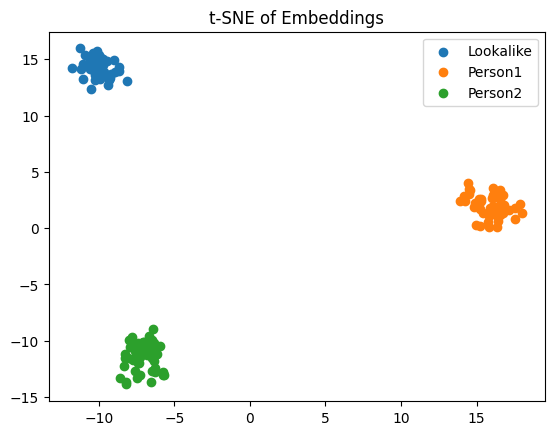

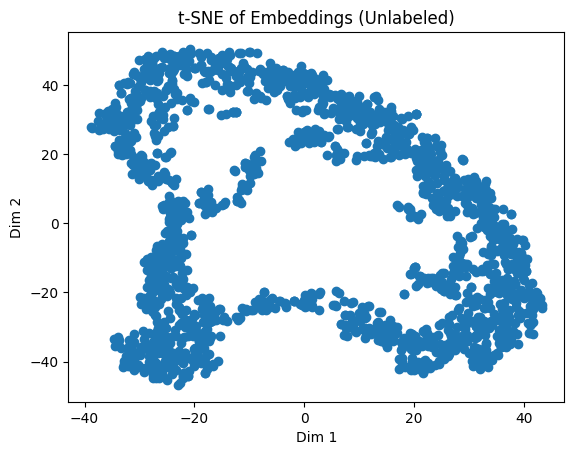

In [52]:
from sklearn.manifold import TSNE

from urllib import request # module for opening HTTP requests
from matplotlib import pyplot as plt # Plotting library
from sklearn.neural_network import MLPClassifier

def plot_tsne_embeddings(embeddings, labels):
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure()

    for cls, name in zip([0,1,2], ["Lookalike", "Person1", "Person2"]):
        idx = labels == cls
        plt.scatter(emb_2d[idx, 0], emb_2d[idx, 1], label=name)

    plt.legend()
    plt.title("t-SNE of Embeddings")
    plt.show()

# call
plot_tsne_embeddings(embeddings, labels)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_unlabeled(embeddings, perplexity=30, random_state=42):
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init='pca',
        learning_rate='auto'
    )

    emb_2d = tsne.fit_transform(embeddings)

    plt.figure()
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1])
    plt.title("t-SNE of Embeddings (Unlabeled)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.show()

# call
plot_tsne_unlabeled(embeddings_test)